## Setup

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [22]:
import pandas as pd
import numpy as np
import cv2
import os
from datetime import datetime
from PIL import Image
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL import Image, ImageDraw

from src.cropping import get_sector_polygons, extract_sector, assign_cards_to_players, show_sectors
from src.active import detect_active_player
from src.segmentation_border import segmented_cards
from src.classify import classify_card
from src.config import load_config, set_global_config

In [12]:
# Check is at least python 3.9
import sys 
assert (sys.version_info.major >= 3) and (sys.version_info.minor >= 9)

# Remove cached modules
import sys
sys.modules.pop("src.active", None)

<module 'src.active' from '/Users/pedrobaeza/Desktop/Image and pattern recognition/Project/ee-451-final/src/active.py'>

In [19]:
img_dir = Path('/Users/pedrobaeza/Desktop/Image and pattern recognition/Data para projecto/iapr-26-uno-vision-challenge/train_images')
image_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))
sample_path = random.choice(image_paths)
img = Image.open(sample_path)

## Component 1: Spatial Layout & Player Region Cropping

In this section we cropped the images into 5 sectors (Player 1, 2, 3, 4 and center). We did this so in the future steps we can know who is the active player and which card belongs to who. The way that we defined the regions was with pure visualization. We observed all the training images and saw that they had a similar pattern that we could follow and encase the cards to their respective player. 

For this spatial layout we call a Python script in src ("cropping.py") that has all the functions that we are going to need in the rest of the pipeline. 

get_sector_polygons(img) receives the image and divides the image in 5 sectors, where we previously know the coordinates of the polygons. The coordinates were the ones that we assigned by observing all the training data and taking the best line segmentations. 

show_sectors(img_path) we can use this function to visualize the sectors and see that it has a high fidelity. 

extract_sector is used for the active player section, it is used to prepare each sector previously taken so it can be analyzed separately.

point_in_polygon is used after detecting the cards, it will tell the sector that the card belongs to.

assign_cards_to_players assigns every card to the player in an array to be ready for the submission.

This method reduces computational load by pre-localizing detection to relevant regions, enables handling of overlapping cards by using their centroid positions and limits classification to cards in valid player positions, reducing false positives.

In [20]:
# Get sector polygons for player regions
polygons = get_sector_polygons(img)

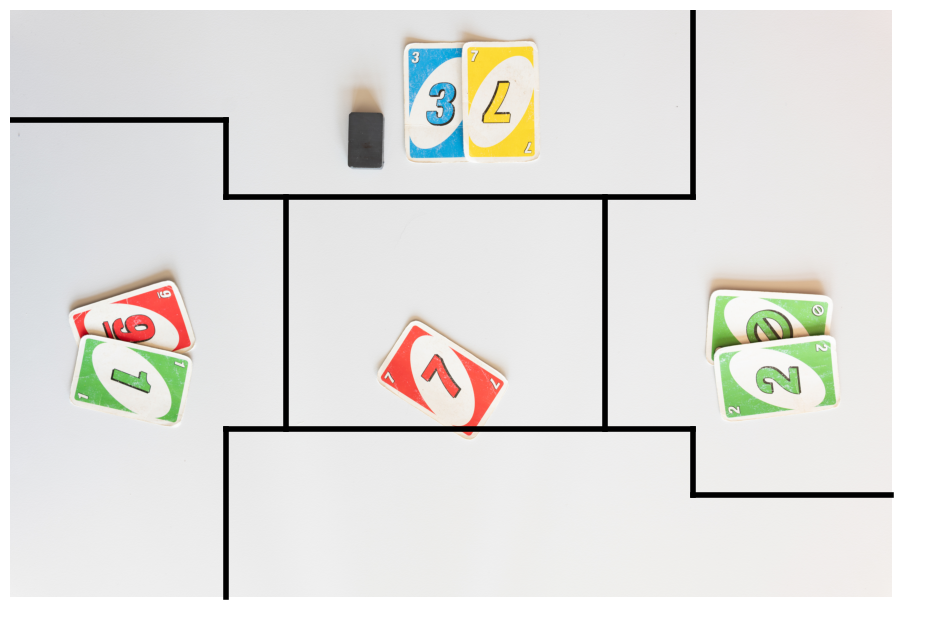

In [24]:
show_sectors(sample_path)

## Component 2: Active Player Detection

### Overview

This explains the design and implementation of `active.py`, a computer-vision module that automatically identifies which player is currently active in an UNO game image.

The module works by:
1. Classifying the image background type (noisy vs. white)
2. Segmenting the image into five spatial sectors (four players + center)
3. Detecting a player-specific marker in each sector
4. Returning the sector that contains the marker as the active player

Two marker types are supported, depending on background:
- **Yellow circular marker** — used when the background is noisy/textured
- **Black rectangular marker** — used when the background is white/clean

---
### 1. Imports and Setup

In [31]:
import pandas as pd
import numpy as np
import cv2
import os
from datetime import datetime
from PIL import Image

In [32]:
# Check is at least python 3.9
import sys 
assert (sys.version_info.major >= 3) and (sys.version_info.minor >= 9)

# Remove cached modules
import sys
sys.modules.pop("src.active", None)

<module 'src.active' from '/Users/pedrobaeza/Desktop/Image and pattern recognition/Project/ee-451-final/src/active.py'>

In [33]:
from src.active import detect_active_player

### 2. Spatial Constants — Image Layout

The module uses fixed pixel coordinates to divide the game image into player sectors. These constants define the boundaries of each region.

```python
X_LEFT      = 980
X_MID_LEFT  = 1250
X_MID_RIGHT = 2700
X_RIGHT     = 3100

Y_TOP_LEFT      = 500
Y_TOP           = 850
Y_BOTTOM        = 1900
Y_BOTTOM_RIGHT  = 2200
```

These values were tuned empirically for the specific camera/table setup used in the dataset. If the camera angle or resolution changes, these would need to be recalibrated.

### 3. Image Classification — Noisy vs. White Background

#### `is_image_noisy(img)`

Before any detection, the pipeline first classifies the image background type. This drives which marker detection strategy to use.

**Method:** Standard deviation of pixel intensities across the entire image.

```python
def is_image_noisy(img: np.ndarray) -> bool:
    return bool(img.std() > 45)
```

- A **high std** (> 45) → lots of color variation → noisy/textured background → look for **yellow circle**
- A **low std** (≤ 45) → mostly uniform → white background → look for **black rectangle**

### 4. Image Segmentation into Sectors

#### `get_sector_polygons(img)`

Returns a dictionary of polygon coordinates for each of the five sectors: `p1`, `p2`, `p3`, `p4`, and `Center`.

Each polygon is a list of `(x, y)` vertices. The polygons are **non-rectangular** — they are L-shaped or trapezoid-like to match the physical layout of the game table as seen from above.

| Sector | Position |
|--------|----------|
| `p3`   | Top-left region |
| `p4`   | Left side |
| `p2`   | Right side |
| `p1`   | Bottom region |
| `Center` | Center card pile area |


#### `extract_sector(img, polygon)`

For each sector polygon, this function:
1. Creates a binary **mask** matching the polygon shape
2. Applies the mask to the original image (non-mask areas are set to white)
3. Crops to the bounding box of the mask

**Returns:** `(sector_crop, mask_crop)` — both as PIL Images

The mask is passed along so that subsequent detection functions can apply it again if needed (e.g., to ignore white-padded areas).

### 5. Black Rectangular Marker Detection

#### `detect_black_rectangular_marker_debug(sector_img, mask, debug=False)`

Used when the image has a **white background**. The active player has a small black rectangular token in their sector.

##### Pipeline

| Step | Operation | Detail |
|------|-----------|--------|
| 1 | Grayscale conversion | `cv2.COLOR_RGB2GRAY` |
| 2 | Thresholding | `THRESH_BINARY_INV` at value 150 — pixels darker than 150 become white in mask |
| 3 | Apply sector mask | Remove any detections outside the current sector polygon |
| 4 | Morphological cleanup | `MORPH_OPEN` then `MORPH_CLOSE` with 11×11 kernel — removes noise and fills gaps |
| 5 | Find contours | `cv2.RETR_EXTERNAL` + `CHAIN_APPROX_SIMPLE` |
| 6 | Filter contours | Area > 35,000 px², 4–8 vertices, aspect ratio 0.45–1.65 |

Returns `True` as soon as any contour passes all filters.

#### Thresholding

A grayscale threshold of `150` (inverted binary) is used to isolate dark regions. The threshold is intentionally lenient rather than strict (e.g., `< 80`) because, in real captures, the black marker is often affected by light reflection, causing it to appear dark grey rather than pure black. A stricter threshold frequently failed to detect the marker entirely.

#### Morphological Cleanup

Morphological opening and closing operations using an `11×11` kernel are applied to remove small noise artifacts and fill gaps within the detected dark region. This produces a cleaner and more coherent blob for downstream contour extraction.

#### Contour Analysis

Contours are extracted from the cleaned mask and filtered using the following constraints:

- **Minimum area ≥ 35,000 px²**  
  Removes small shadows or incidental dark objects that are unlikely to correspond to the marker.

- **Vertex count between 4 and 8**  
  A clean rectangular contour ideally approximates to 4 vertices. However, in practice, shadows or neighboring card boundaries can merge with the marker contour, producing irregular polygonal shapes with additional edges. Allowing up to 8 vertices improves robustness to these imperfect boundaries without becoming overly permissive to arbitrary shapes.

- **Aspect ratio between 0.55 and 1.65**  
  Constrains the bounding box to roughly square-to-slightly-rectangular proportions consistent with the physical marker card.

The lenient vertex-count range directly addresses the observed failure mode in which shadows cast by the marker or adjacent cards attach to the detected contour, producing outlines that are no longer clean quadrilaterals. Using a stricter vertex constraint caused many true positives to be rejected.

### 6. Yellow Circular Marker Detection

#### `detect_yellow_circular_marker_hough(sector_img, mask, ..., debug=False)`

Used when the image has a **noisy/textured background**. The active player has a yellow circular token in their sector.

##### Pipeline

| Step | Operation | Detail |
|------|-----------|--------|
| 1 | HSV conversion | More robust to lighting variation than RGB |
| 2 | Yellow masking | `cv2.inRange` with hue range (22–28), min saturation 100, min value 100 |
| 3 | Apply sector mask | Restrict to current player's region |
| 4 | Morphological cleanup | `MORPH_OPEN` with 3×3 kernel |
| 5 | Hough Circle Transform | `cv2.HoughCircles` with `HOUGH_GRADIENT` |
| 6 | Validate each circle | Yellow pixel ratio ≥ 70% AND average HSV saturation ≥ 20% |

##### Key parameters

| Parameter | Default | Role |
|-----------|---------|------|
| `hue_range` | (22, 28) | Tight yellow hue window in HSV |
| `min_radius` / `max_radius` | 60 / 100 | Expected marker size |
| `yellow_threshold` | 0.70 | At least 70% of the detected circle must be yellow |
| `saturation_threshold` | 0.20 | Filters out white regions (which pass hue but have low saturation) |

The dual-filter (yellow ratio + saturation) is the key design decision that prevents false positives from white or off-color regions that might otherwise pass the hue check.

Returns `True` if at least one valid circle is found.

#### Design Decisions
Initial approach — contour detection: The first attempted approach used contour detection on the HSV-thresholded yellow mask. This produced frequent false positives, particularly for UNO wild cards, which have a thin yellow border around their edges. The contour detector latched onto this border, misclassifying cards as active-player markers.

##### Revised Approach — Hough Circle Transform

Switching to `cv2.HoughCircles` resolved this issue, since it explicitly enforces a circular geometry constraint. The transform was applied to the cleaned yellow binary mask using tightly constrained parameters:

- `minRadius=60`, `maxRadius=100`  
  Restricts detection to the expected physical size of the marker token.

- `dp=1.5`, `param1=50`, `param2=30`  
  Controls accumulator resolution and edge/circle sensitivity.

##### Residual False Positive: Yellow Skip Cards

UNO skip cards share a nearly identical yellow hue and, when viewed from certain angles, can fall within the accepted radius range. To reject these false positives, two additional filters were applied to each detected circle:

1. **Yellow ratio ≥ 70%**  
   The fraction of pixels inside the detected circle classified as yellow (in HSV space) must exceed `0.70`.  
   Since a skip card’s circular region only partially fills the detection window, it typically produces a lower yellow ratio.

2. **Average saturation ≥ 20%**  
   The mean HSV saturation across all pixels inside the circle must remain sufficiently high.  
   This removes near-white regions (e.g., card text or overexposed surfaces) that may fall within the yellow hue range but exhibit very low chroma.

Both conditions must be satisfied simultaneously for a circle to be accepted as a valid marker.



### 7. Main Pipeline — `detect_active_player`

This is the top-level function that orchestrates the full detection pipeline.

```
Input image (numpy array / PIL Image / file path)
        │
        ▼
  Normalize to numpy + PIL
        │
        ▼
  is_image_noisy?
   ┌────┴────┐
  Yes       No
   │         │
Yellow    Black
circle  rectangle
   └────┬────┘
        ▼
  Segment into sectors (p1–p4 + Center)
        │
        ▼
  For each player sector:
    → run marker detection
    → record True/False
        │
        ▼
  Return first sector with marker = active player
```

#### Input flexibility
The function accepts three input types:
- `str` — file path (loaded with PIL)
- `np.ndarray` — already-loaded array
- `PIL.Image` — already-opened PIL image

#### Return value
```python
{
    'active_player': 'p1',          # or p2, p3, p4, or None
    'is_noisy': True,
    'marker_type': 'yellow_circle', # or 'black_rectangle'
    'sectors': {...},               # dict of sector PIL images
    'detections': {...},            # bool per sector
    'all_detections': {...}         # same as detections (alias)
}
```

> **Note:** Only the first sector found with a marker is returned as `active_player`. If no sector has a marker, `active_player` will be `None`.

In [ ]:
  # Load image
image_path_black_marker = r"C:\Users\Vidhi\ee-451-final\data\train_images\L1000770.jpg"

img_black_bgr = cv2.imread(image_path_black_marker)
img_black_rgb = cv2.cvtColor(img_black_bgr, cv2.COLOR_BGR2RGB)
img_pil_black_rgb = Image.fromarray(img_black_rgb)

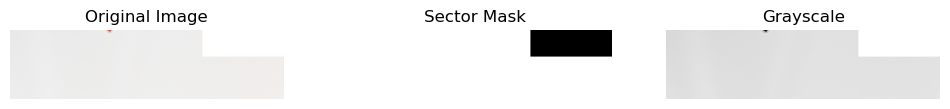

Gray min: 113 Gray max: 255 Gray mean: 239.49485103683233


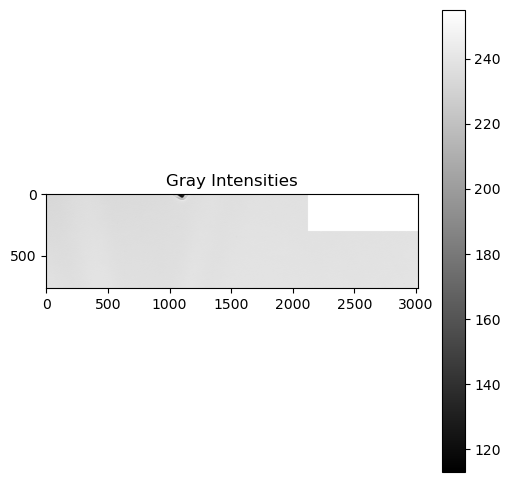

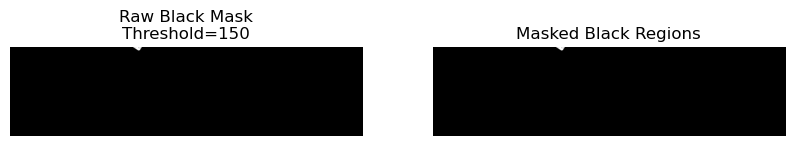

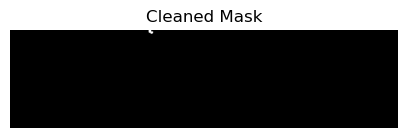

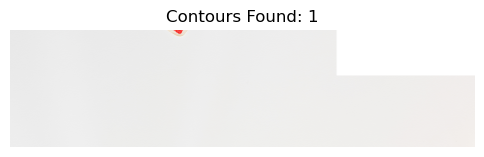


Contour 0
Area: 649.00
Rejected: area too small

❌ No black rectangular marker detected


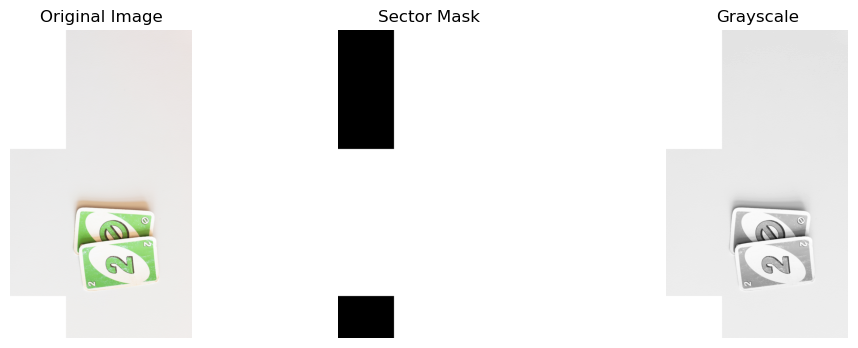

Gray min: 18 Gray max: 255 Gray mean: 234.02632334952645


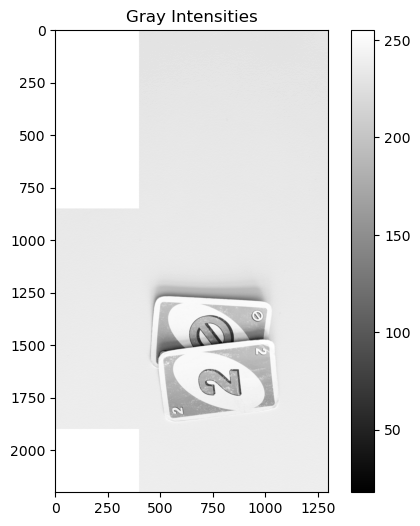

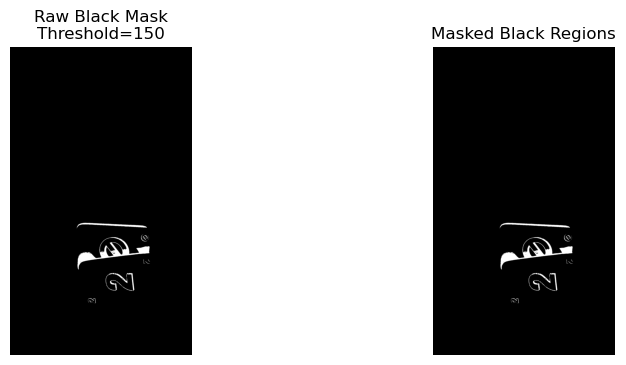

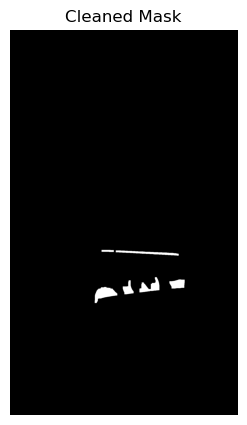

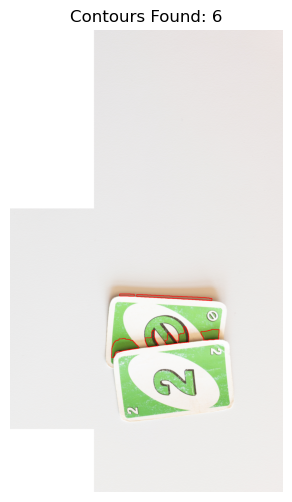


Contour 0
Area: 6157.50
Rejected: area too small

Contour 1
Area: 2573.50
Rejected: area too small

Contour 2
Area: 3563.50
Rejected: area too small

Contour 3
Area: 4516.00
Rejected: area too small

Contour 4
Area: 4020.00
Rejected: area too small

Contour 5
Area: 698.00
Rejected: area too small

❌ No black rectangular marker detected


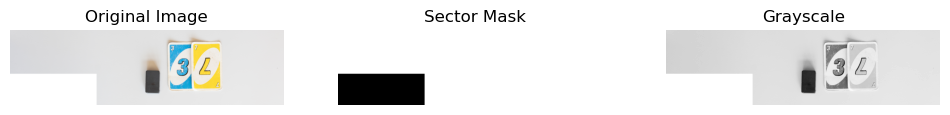

Gray min: 34 Gray max: 255 Gray mean: 224.65783639029297


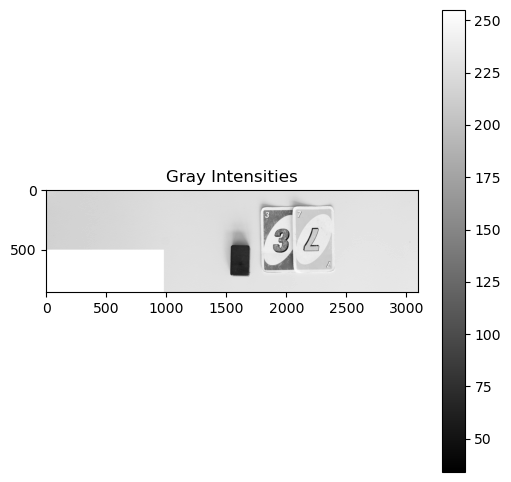

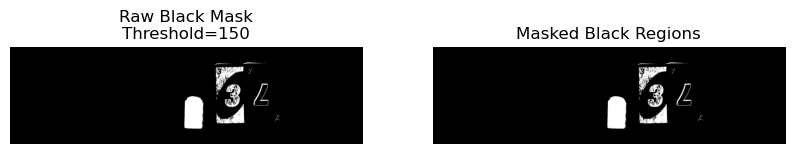

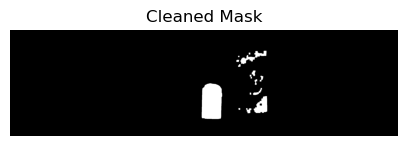

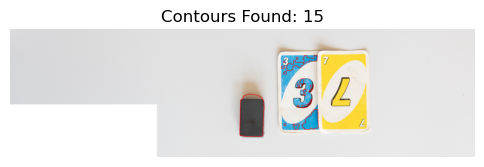


Contour 0
Area: 994.50
Rejected: area too small

Contour 1
Area: 163.50
Rejected: area too small

Contour 2
Area: 9424.50
Rejected: area too small

Contour 3
Area: 163.00
Rejected: area too small

Contour 4
Area: 1215.50
Rejected: area too small

Contour 5
Area: 41709.50
Vertices: 6
Bounding Box: x=1532, y=432, w=164, h=284
Aspect Ratio: 0.58


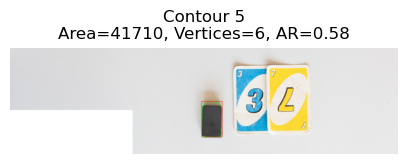

✅ Black rectangular marker detected


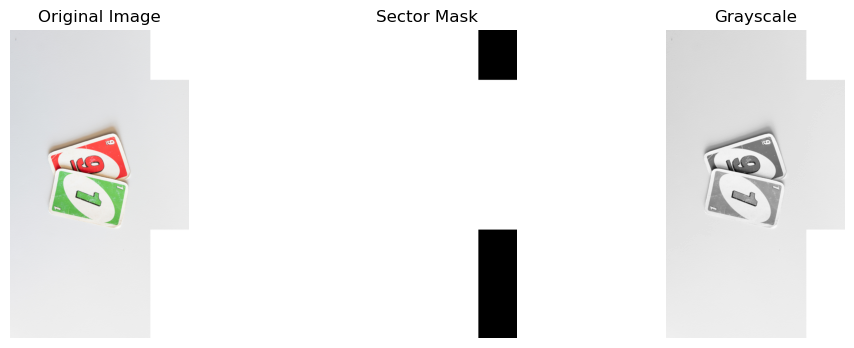

Gray min: 17 Gray max: 255 Gray mean: 227.13282546950413


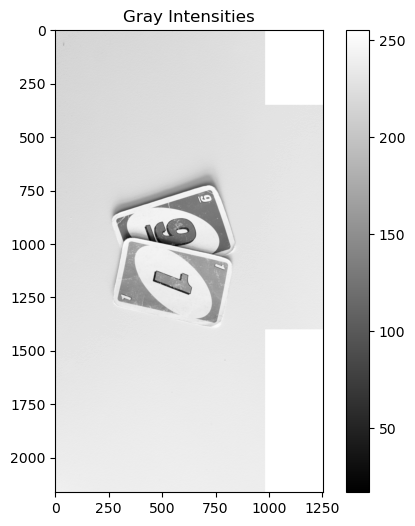

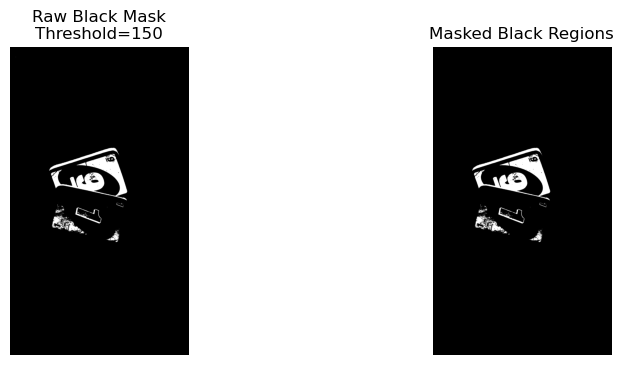

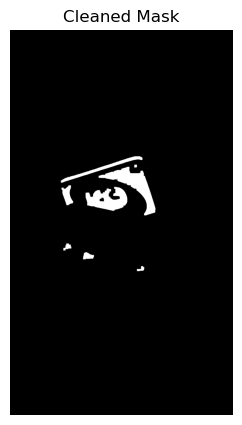

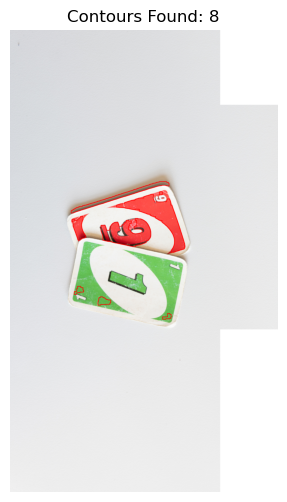


Contour 0
Area: 613.00
Rejected: area too small

Contour 1
Area: 1644.00
Rejected: area too small

Contour 2
Area: 924.00
Rejected: area too small

Contour 3
Area: 19486.00
Rejected: area too small

Contour 4
Area: 3908.50
Rejected: area too small

Contour 5
Area: 24283.50
Rejected: area too small

Contour 6
Area: 203.00
Rejected: area too small

Contour 7
Area: 7903.50
Rejected: area too small

❌ No black rectangular marker detected
Active player: p3


In [34]:
active_player = detect_active_player(img,debug = True)["active_player"]
print(f"Active player: {active_player}")

In [ ]:
  # Load image
image_path_yellow_marker = r"C:\Users\Vidhi\ee-451-final\data\train_images\L1000977.jpg"

img_yellow_bgr = cv2.imread(image_path_yellow_marker)
img_yellow_rgb = cv2.cvtColor(img_yellow_bgr, cv2.COLOR_BGR2RGB)
img_pil_yellow_rgb = Image.fromarray(img_yellow_rgb)

In [ ]:
active_player = detect_active_player(img_yellow_rgb,debug = True)["active_player"]
print(f"Active player: {active_player}")